In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score,mean_squared_error

In [5]:
x,y=load_diabetes(return_X_y=True)

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=0,test_size=0.2)

In [7]:
x_train.shape

(353, 10)

In [8]:
# applying linear Regression
lr=LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
y_pred=lr.predict(x_test)

In [10]:
print("r2_score",r2_score(y_test,y_pred))
print("mse",np.sqrt(mean_squared_error(y_test,y_pred)))

r2_score 0.3322332173106183
mse 58.517171277315626


In [11]:
# now we will apply ridge
r=Ridge(alpha=0.001)
r.fit(x_train,y_train)

,alpha,0.001
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [12]:
y_pred=r.predict(x_test)

In [13]:
print("r2_score",r2_score(y_test,y_pred))
print("mse",np.sqrt(mean_squared_error(y_test,y_pred)))

r2_score 0.33163140890503495
mse 58.54353392039306


- both the score are almost same that's why there is no overfitting

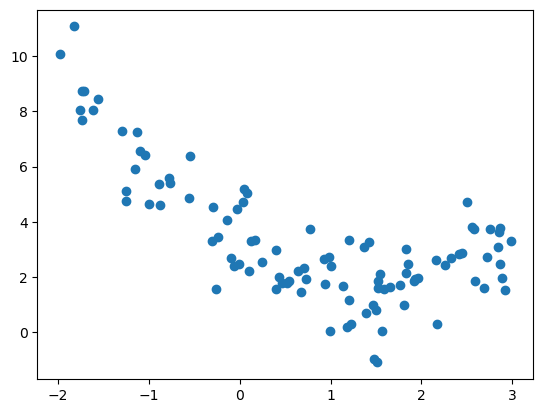

In [14]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

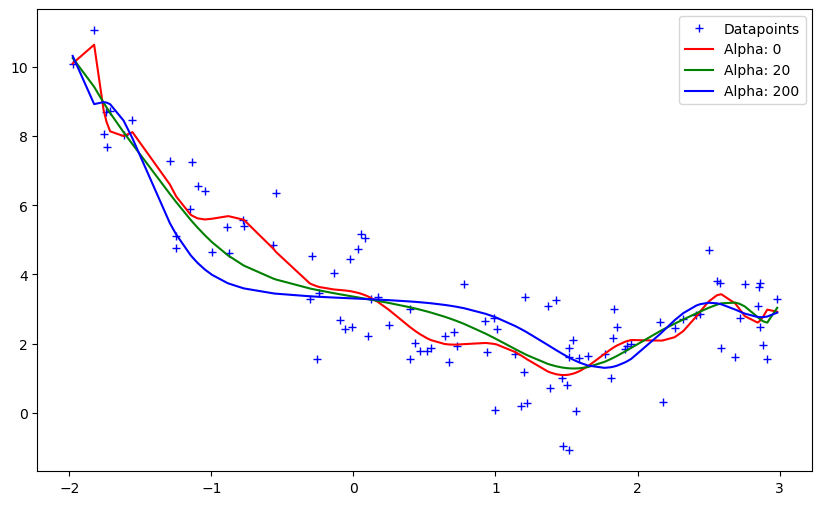

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()

# now we will make our owm class for ridge_regularization

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.compose import ColumnTransformer
from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge

In [17]:
x,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

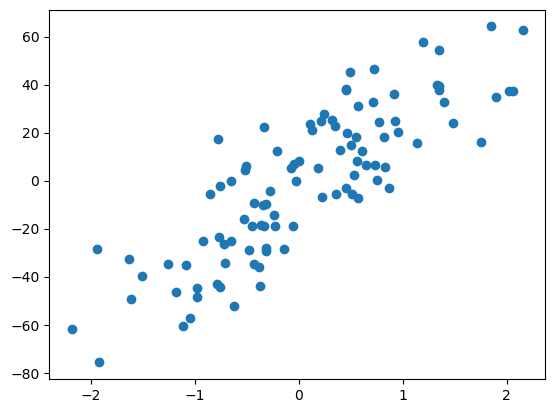

In [18]:
plt.scatter(x,y)

In [19]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=0,test_size=0.2)

In [20]:
x_train.shape[0]

80

In [21]:
# now we will train the model 

In [22]:
lr=LinearRegression()
lr.fit(x_train,y_train)
y_pred=lr.predict(x_test)

In [23]:
print("r2_score",r2_score(y_test,y_pred))

r2_score 0.6885177188668723


In [24]:
r1=Ridge(alpha=0)
r1.fit(x_train,y_train)
print(r1.coef_)
print(r1.intercept_)

[27.66905703]
-2.6537533288365944


In [25]:
r2=Ridge(alpha=10)
r2.fit(x_train,y_train)
print(r2.coef_)
print(r2.intercept_)

[24.34737064]
-2.545591720235806


In [26]:
r3=Ridge(alpha=100)
r3.fit(x_train,y_train)
print(r3.coef_)
print(r3.intercept_)

[11.70290532]
-2.133859380831125


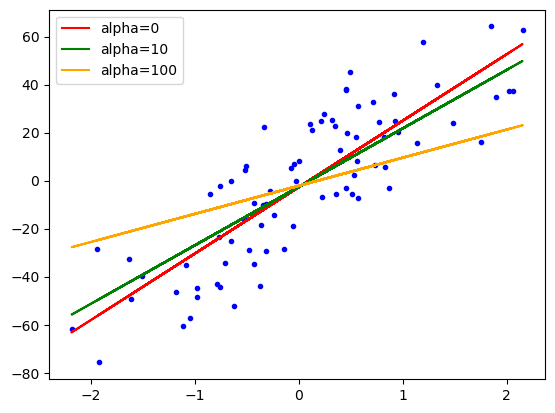

In [27]:
plt.plot(x_train,y_train,'b.')
plt.plot(x_train,r1.predict(x_train),color='red',label='alpha=0')
plt.plot(x_train,r2.predict(x_train),color='green',label='alpha=10')
plt.plot(x_train,r3.predict(x_train),color='orange',label='alpha=100')
plt.legend()

- here we will make our own class

In [28]:
class meraRidge:
    def __init__(self,alpha=0.1):
        self.alpha=alpha
        self.m=None
        self.b=None

    def fit(self,x_train,y_train):
        den=0
        num=0
        for i in range(x_train.shape[0]):
            den=den + (y_train[i] - y_train.mean()) * (x_train[i] - x_train.mean())
            num=num + (x_train[i] - x_train.mean()) * (x_train[i] - x_train.mean())
        self.m=den/(num + self.alpha)
        self.b=y_train.mean() - self.m*x_train.mean()
        print(self.m,self.b)

    def predict(self,x_test):
        y_pred=self.m * x_test + self.b
        return y_pred

In [29]:
lr=meraRidge(alpha=100)
lr.fit(x_train,y_train)

[11.70290532] [-2.13385938]


In [30]:
lr.predict(x_test)

array([[ -6.09667675],
       [ 14.24129537],
       [ -7.44408054],
       [ 13.66726177],
       [ 13.60773856],
       [ -6.63313127],
       [  5.35464217],
       [  6.68739718],
       [  3.73090293],
       [ -5.81861363],
       [-11.1996324 ],
       [  4.96147937],
       [ 13.66864384],
       [ -4.85391735],
       [  0.03054557],
       [  6.31522933],
       [-12.99807863],
       [ -4.56045327],
       [-16.89831431],
       [-10.57165029]])

# Ridge regularization for n dimensional data

In [31]:
from sklearn.datasets import load_diabetes

In [32]:
x,y=load_diabetes(return_X_y=True)

In [33]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=0,test_size=0.2)

In [34]:
x_train.shape

(353, 10)

In [35]:
from sklearn.linear_model import Ridge

In [36]:
r=Ridge(alpha=0.1,solver="cholesky")

In [37]:
r.fit(x_train,y_train)

,alpha,0.1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'cholesky'
,positive,False
,random_state,None


In [38]:
y_pred=r.predict(x_test)

In [39]:
print("r2_score",r2_score(y_test,y_pred))
print("intercept",r.intercept_)
print("coef",r.coef_)

r2_score 0.3423049448970741
intercept 152.3052251107143
coef [ -18.93029239 -205.95750389  520.88560398  278.43533926  -81.8776638
 -108.96163394 -209.97654965  117.75990964  457.61641721   69.00373659]


# now we will create our own class for this n dimensional ridge regularization

In [40]:
class meraRidge:
    def __init__(self,alpha=0.1):
        self.alpha=alpha
        self.coef=None
        self.intercept=None
    def fit(self,x_train,y_train):
        x_train=np.insert(x_train,0,1,axis=1)
        I=np.identity(x_train.shape[1])
        I[0][0]=0
        result = np.linalg.inv(np.dot(x_train.T,x_train) + self.alpha * I).dot(x_train.T).dot(y_train)
        self.intercept=result[0]      
        self.coef=result[1:]
        print(self.coef,self.intercept)

    def predict(self,x_test):
        return np.dot(x_test,self.coef) + self.intercept

In [41]:
lpg=meraRidge()
lpg.fit(x_train,y_train)

[ -18.93029239 -205.95750389  520.88560398  278.43533926  -81.8776638
 -108.96163394 -209.97654965  117.75990964  457.61641721   69.00373659] 152.30522511071428


- so this is our class

# now we will create our own class for ridge regression using gradient descent

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.datasets import load_diabetes

In [43]:
x,y=load_diabetes(return_X_y=True)

In [44]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=0,test_size=0.2)

In [45]:
x_train.shape

(353, 10)

In [58]:
class MERAridge:
    def __init__(self,epochs=50,lr=0.1,alpha=0.1):
        self.lr=lr
        self.epochs=epochs
        self.alpha=alpha
        self.result=None
        self.coef=None
        self.intercept=None

    def fit(self,x_train,y_train):
        self.coef=np.ones(x_train.shape[1])
        self.intercept=0
        self.result=np.insert(self.coef,0,self.intercept)
        x_train=np.insert(x_train,0,1,axis=1)
        for i in range(self.epochs):
            slope=np.dot(x_train.T,x_train).dot(self.result) - np.dot(x_train.T,y_train) + (self.alpha * self.result)
            self.result=self.result- (self.lr* slope)
        print(self.result)
        self.coeff=self.result[1:]
        self.intercept=self.result[0]
    def predict(self,x_test):
        y_pred=np.dot(x_test,self.coeff) +self.intercept
        return y_pred

In [59]:
lav=MERAridge(epochs=300,lr=0.001,alpha=0.001)
lav.fit(x_train,y_train)

[ 151.77056393   39.49982504   -8.35412265  183.6458823   120.42215939
   36.09624938   18.41383582 -112.44535689  108.69598466  167.50674001
   96.8311276 ]


In [60]:
lav.predict(x_test)

array([185.08644987, 189.57818207, 159.51808112, 133.52983343,
       150.25477798, 184.23961996, 127.44312175, 174.48564518,
       133.36217893, 167.56468851, 140.16078305, 176.8816415 ,
       127.95104317, 111.73316216, 205.47229573, 122.34914479,
       139.26828151, 105.75368748, 107.93602878, 189.56485819,
       154.47010323, 139.87162573, 158.22737572, 132.29412394,
       176.19130044, 158.69346771, 130.87614939, 115.48244414,
       156.94307633, 164.71490429, 170.61691343, 114.77016179,
       131.94200736, 147.48043159, 164.18516086, 165.07804935,
       158.33349646, 172.81171845, 142.20365224, 173.64405368,
       121.03761874, 168.97048352, 154.2560457 , 154.08865179,
       175.63122858, 114.09886204, 139.90106251, 140.46984649,
       153.05413889, 185.95492666, 150.95578929, 118.42570257,
       148.48800105, 163.28256537, 177.69375624, 178.975571  ,
       176.33697024, 113.82025967, 161.98680221, 169.47550327,
       161.48082084, 144.48716969, 159.28204533, 148.86

In [55]:
y_pred

array([230.86996561, 241.27351293, 163.65948661, 122.37372852,
       180.32205705, 249.21099804, 113.95543576, 185.86592015,
       151.88414626, 223.80639887, 162.79300052, 177.83977276,
       111.64758412,  95.45787218, 238.10781592,  95.96622318,
       150.64153462,  72.26486876, 103.03676478, 215.27265237,
       191.49917527, 154.62674969, 158.65148774, 155.26431076,
       193.87080932, 164.47052071, 116.69624192,  89.17933869,
       183.09986762, 159.74776626, 172.44966795,  90.75028532,
       143.89683313, 143.37197918, 143.56865245, 190.62154477,
       162.94252554, 184.69527002, 132.94851938, 200.50953139,
        88.42990641, 163.98315939, 144.32374783, 178.01602975,
       178.0003126 ,  80.47903102, 137.50918336, 140.13816022,
       124.17511157, 227.34116352, 157.9672736 ,  83.43934014,
       157.05115068, 155.86036643, 227.39294985, 171.44626748,
       186.87566814, 117.69477765, 136.88743915, 168.49628869,
       204.45067987, 165.7107867 , 161.26396908, 115.17